In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (
    classification_report, confusion_matrix, accuracy_score,
    roc_auc_score, roc_curve, ConfusionMatrixDisplay
)
from sklearn.cluster import KMeans
from sklearn.decomposition import PCA
from sklearn.metrics import silhouette_score

sns.set_style("whitegrid")

In [2]:
df = pd.read_csv("diabetes.csv")
print("Shape:",df.shape)
print(df.head())
print(df.info())

Shape: (768, 9)
   Pregnancies  Glucose  BloodPressure  SkinThickness  Insulin   BMI  \
0            6      148           72.0             35    169.5  33.6   
1            1       85           66.0             29    102.5  26.6   
2            8      183           64.0             32    169.5  23.3   
3            1       89           66.0             23     94.0  28.1   
4            0      137           40.0             35    168.0  43.1   

   DiabetesPedigreeFunction  Age  Outcome  
0                     0.627   50        1  
1                     0.351   31        0  
2                     0.672   32        1  
3                     0.167   21        0  
4                     2.288   33        1  
<class 'pandas.DataFrame'>
RangeIndex: 768 entries, 0 to 767
Data columns (total 9 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   Pregnancies               768 non-null    int64  
 1   Glucose                 

In [3]:
zero_as_missing = ["Glucose", "BloodPressure", "SkinThickness", "Insulin", "BMI"]
print("\nZero-value counts before cleaning:")
print((df[zero_as_missing] == 0).sum())
df[zero_as_missing] = df[zero_as_missing].replace(0, np.nan)
df[zero_as_missing] = df[zero_as_missing].fillna(df[zero_as_missing].median())
print("\nMissing values after imputation:")
print(df.isnull().sum())
print("\nDuplicate rows:", df.duplicated().sum())
df = df.drop_duplicates()


Zero-value counts before cleaning:
Glucose          0
BloodPressure    0
SkinThickness    0
Insulin          0
BMI              0
dtype: int64

Missing values after imputation:
Pregnancies                 0
Glucose                     0
BloodPressure               0
SkinThickness               0
Insulin                     0
BMI                         0
DiabetesPedigreeFunction    0
Age                         0
Outcome                     0
dtype: int64

Duplicate rows: 0



Summary statistics:
       Pregnancies     Glucose  BloodPressure  SkinThickness     Insulin  \
count   768.000000  768.000000     768.000000     768.000000  768.000000   
mean      3.845052  121.677083      72.389323      29.089844  141.753906   
std       3.369578   30.464161      12.106039       8.890820   89.100847   
min       0.000000   44.000000      24.000000       7.000000   14.000000   
25%       1.000000   99.750000      64.000000      25.000000  102.500000   
50%       3.000000  117.000000      72.000000      28.000000  102.500000   
75%       6.000000  140.250000      80.000000      32.000000  169.500000   
max      17.000000  199.000000     122.000000      99.000000  846.000000   

              BMI  DiabetesPedigreeFunction         Age     Outcome  
count  768.000000                768.000000  768.000000  768.000000  
mean    32.434635                  0.471876   33.240885    0.348958  
std      6.880498                  0.331329   11.760232    0.476951  
min     18.200

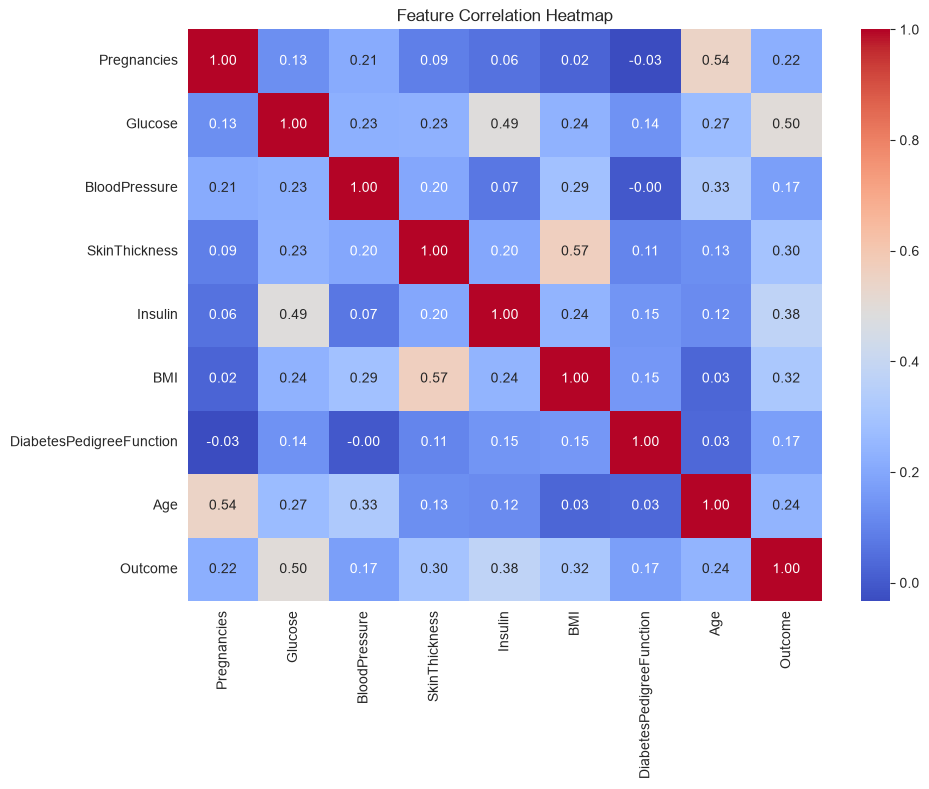

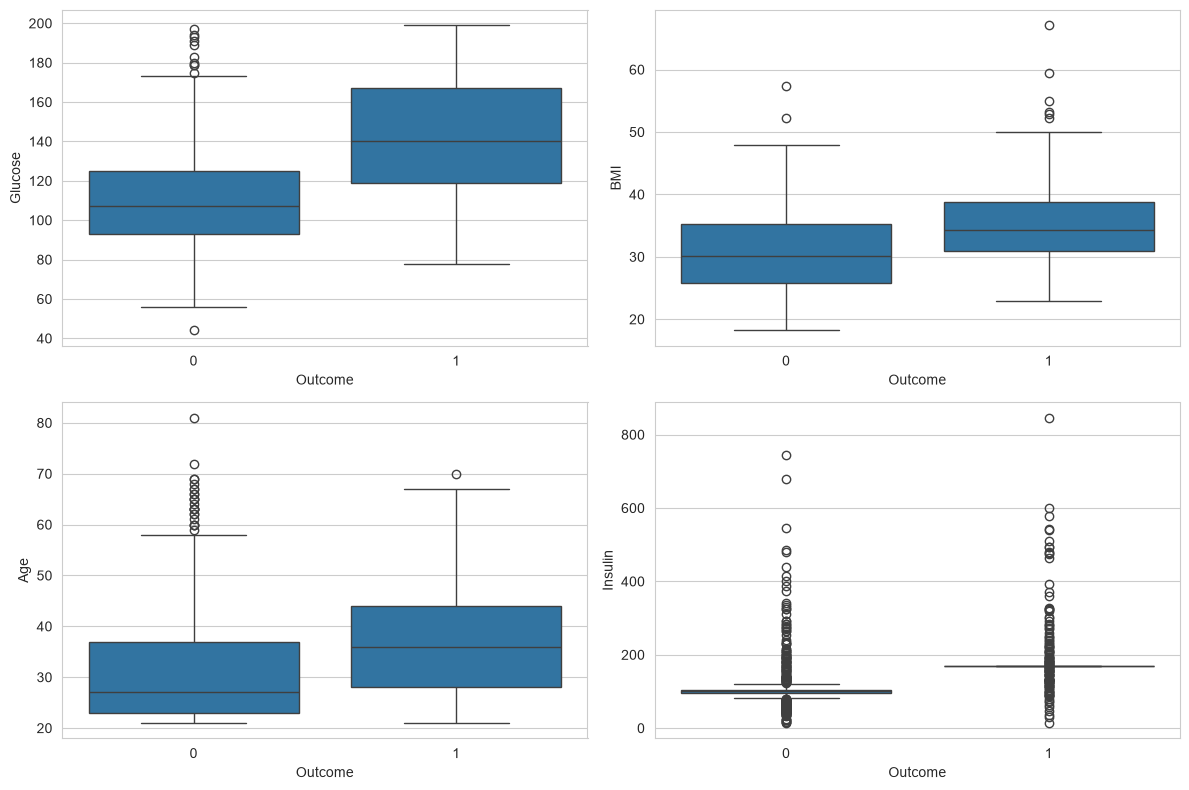

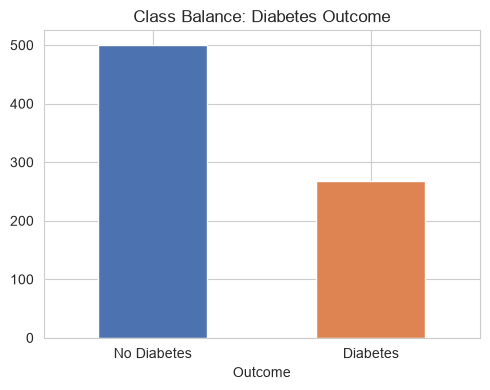

In [6]:
print("\nSummary statistics:")
print(df.describe())

print("\nClass balance (Outcome):")
print(df["Outcome"].value_counts(normalize=True))

plt.figure(figsize=(10, 8))
sns.heatmap(df.corr(), annot=True, fmt=".2f", cmap="coolwarm")
plt.title("Feature Correlation Heatmap")
plt.tight_layout()
plt.show()

fig, axes = plt.subplots(2, 2, figsize=(12, 8))
sns.boxplot(x="Outcome", y="Glucose", data=df, ax=axes[0, 0])
sns.boxplot(x="Outcome", y="BMI", data=df, ax=axes[0, 1])
sns.boxplot(x="Outcome", y="Age", data=df, ax=axes[1, 0])
sns.boxplot(x="Outcome", y="Insulin", data=df, ax=axes[1, 1])
plt.tight_layout()
plt.show()

plt.figure(figsize=(5, 4))
df["Outcome"].value_counts().plot(kind="bar", color=["#4C72B0", "#DD8452"])
plt.title("Class Balance: Diabetes Outcome")
plt.xticks([0, 1], ["No Diabetes", "Diabetes"], rotation=0)
plt.tight_layout()
plt.show()

In [7]:
X = df.drop("Outcome", axis=1)
y = df["Outcome"]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

scaler = StandardScaler()
X_train_s = scaler.fit_transform(X_train)
X_test_s = scaler.transform(X_test)

In [8]:
log_reg = LogisticRegression(max_iter=1000, random_state=42)
log_reg.fit(X_train_s, y_train)
y_pred_lr = log_reg.predict(X_test_s)

print("\n=== Logistic Regression ===")
print("Accuracy:", accuracy_score(y_test, y_pred_lr))
print(classification_report(y_test, y_pred_lr))


=== Logistic Regression ===
Accuracy: 0.7077922077922078
              precision    recall  f1-score   support

           0       0.77      0.79      0.78       100
           1       0.59      0.56      0.57        54

    accuracy                           0.71       154
   macro avg       0.68      0.67      0.67       154
weighted avg       0.70      0.71      0.71       154




Best Random Forest params: {'max_depth': 5, 'min_samples_leaf': 2, 'n_estimators': 200}
Accuracy: 0.8636363636363636
ROC-AUC: 0.9437037037037037
              precision    recall  f1-score   support

           0       0.89      0.90      0.90       100
           1       0.81      0.80      0.80        54

    accuracy                           0.86       154
   macro avg       0.85      0.85      0.85       154
weighted avg       0.86      0.86      0.86       154



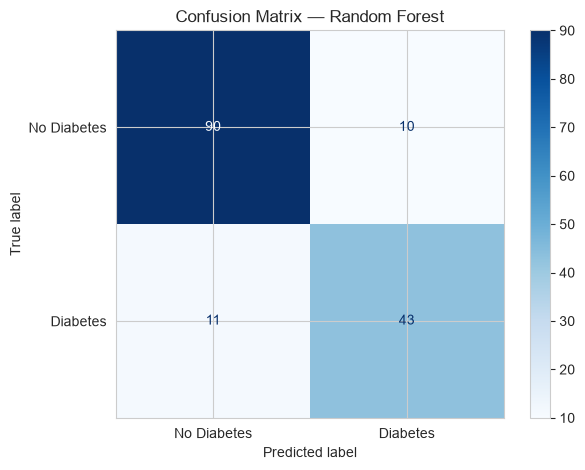

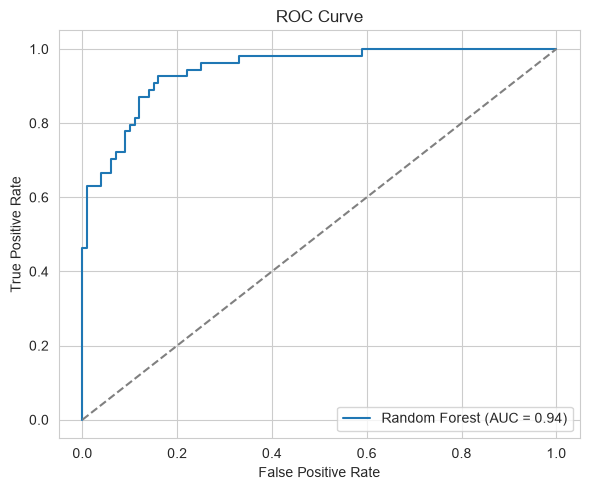

In [10]:
rf = RandomForestClassifier(random_state=42)

param_grid = {
    "n_estimators": [100, 200],
    "max_depth": [None, 5, 10],
    "min_samples_leaf": [1, 2, 4],
}
grid = GridSearchCV(rf, param_grid, cv=5, scoring="accuracy", n_jobs=-1)
grid.fit(X_train_s, y_train)

best_rf = grid.best_estimator_
y_pred_rf = best_rf.predict(X_test_s)
y_proba_rf = best_rf.predict_proba(X_test_s)[:, 1]

print("\nBest Random Forest params:", grid.best_params_)
print("Accuracy:", accuracy_score(y_test, y_pred_rf))
print("ROC-AUC:", roc_auc_score(y_test, y_proba_rf))
print(classification_report(y_test, y_pred_rf))

cm = confusion_matrix(y_test, y_pred_rf)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=["No Diabetes", "Diabetes"])
disp.plot(cmap="Blues")
plt.title("Confusion Matrix — Random Forest")
plt.tight_layout()
plt.show()

fpr, tpr, _ = roc_curve(y_test, y_proba_rf)
plt.figure(figsize=(6, 5))
plt.plot(fpr, tpr, label=f"Random Forest (AUC = {roc_auc_score(y_test, y_proba_rf):.2f})")
plt.plot([0, 1], [0, 1], linestyle="--", color="gray")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve")
plt.legend()
plt.tight_layout()
plt.show()


Feature importances:
Insulin                     0.406243
Glucose                     0.196842
SkinThickness               0.155641
Age                         0.069817
BMI                         0.066832
DiabetesPedigreeFunction    0.039175
Pregnancies                 0.036990
BloodPressure               0.028460
dtype: float64


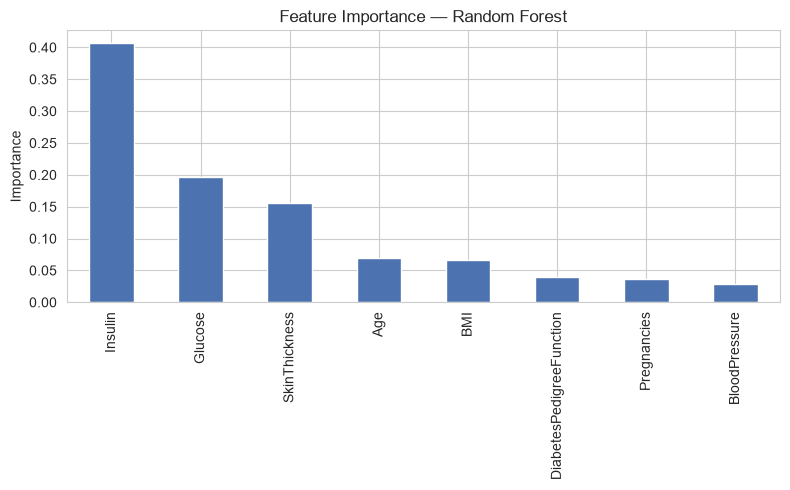

In [12]:
importances = pd.Series(best_rf.feature_importances_, index=X.columns).sort_values(ascending=False)
print("\nFeature importances:")
print(importances)

plt.figure(figsize=(8, 5))
importances.plot(kind="bar", color="#4C72B0")
plt.title("Feature Importance — Random Forest")
plt.ylabel("Importance")
plt.tight_layout()
plt.show()

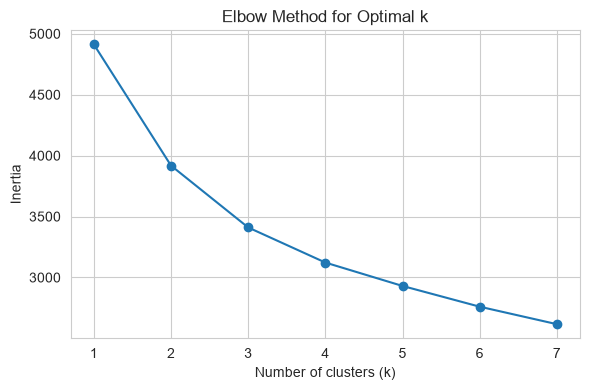


Silhouette score (k=2): 0.20326040065981182

Cluster vs. Actual Outcome crosstab:
Actual Outcome    0    1
Cluster                 
0               291   45
1               109  169


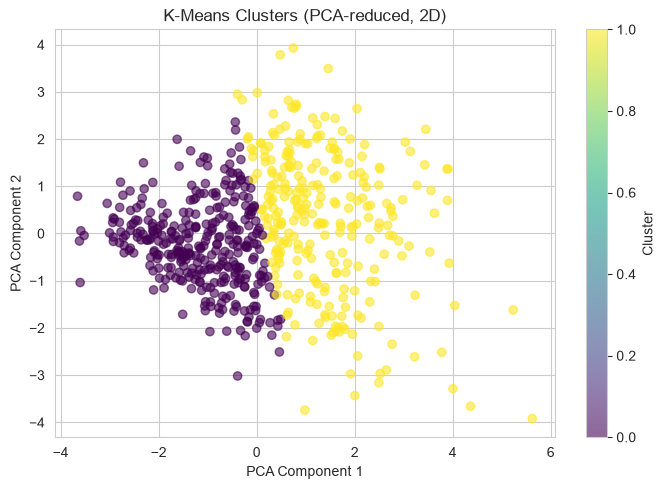

In [14]:
inertias = []
k_range = range(1, 8)
for k in k_range:
    km_test = KMeans(n_clusters=k, random_state=42, n_init=10)
    km_test.fit(X_train_s)
    inertias.append(km_test.inertia_)

plt.figure(figsize=(6, 4))
plt.plot(list(k_range), inertias, marker="o")
plt.xlabel("Number of clusters (k)")
plt.ylabel("Inertia")
plt.title("Elbow Method for Optimal k")
plt.tight_layout()
plt.show()

kmeans = KMeans(n_clusters=2, random_state=42, n_init=10)
clusters = kmeans.fit_predict(X_train_s)

sil_score = silhouette_score(X_train_s, clusters)
print("\nSilhouette score (k=2):", sil_score)

comparison = pd.crosstab(clusters, y_train.values, rownames=["Cluster"], colnames=["Actual Outcome"])
print("\nCluster vs. Actual Outcome crosstab:")
print(comparison)

pca = PCA(n_components=2, random_state=42)
X_pca = pca.fit_transform(X_train_s)

plt.figure(figsize=(7, 5))
scatter = plt.scatter(X_pca[:, 0], X_pca[:, 1], c=clusters, cmap="viridis", alpha=0.6)
plt.xlabel("PCA Component 1")
plt.ylabel("PCA Component 2")
plt.title("K-Means Clusters (PCA-reduced, 2D)")
plt.colorbar(scatter, label="Cluster")
plt.tight_layout()
plt.show()

In [15]:
print("\n" + "=" * 50)
print("SUMMARY — copy these into your report's Evaluation section")
print("=" * 50)
print(f"Logistic Regression accuracy: {accuracy_score(y_test, y_pred_lr):.4f}")
print(f"Random Forest accuracy:       {accuracy_score(y_test, y_pred_rf):.4f}")
print(f"Random Forest ROC-AUC:        {roc_auc_score(y_test, y_proba_rf):.4f}")
print(f"K-Means silhouette score:     {sil_score:.4f}")
print(f"Top 3 important features:     {list(importances.index[:3])}")
print(f"Best RF hyperparameters:      {grid.best_params_}")


SUMMARY — copy these into your report's Evaluation section
Logistic Regression accuracy: 0.7078
Random Forest accuracy:       0.8636
Random Forest ROC-AUC:        0.9437
K-Means silhouette score:     0.2033
Top 3 important features:     ['Insulin', 'Glucose', 'SkinThickness']
Best RF hyperparameters:      {'max_depth': 5, 'min_samples_leaf': 2, 'n_estimators': 200}
